# found some facts

when a language task gets harder, your brain doesn't just work "more"—it shifts to a different network, particularly engaging frontal regions for post-hoc analysis and reanalysis

search for state difference

# input

In [1]:
import mne
import numpy as np
from scipy.signal import welch, coherence
from itertools import combinations

fname_main = "/Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif"

raw = mne.io.read_raw_fif(fname_main, preload=True)

raw.filter(1., 40.)

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 36000 ... 1611999 =     36.000 ...  1611.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
     

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_87663/2398322306.py:8: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=True)


Reading 0 ... 4886999  =      0.000 ...  4886.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)



<Raw | main.fif, 324 x 4887000 (4887.0 s), ~11.80 GiB, data loaded>

In [6]:
import mne
import numpy as np

# Get sensor positions in head coordinates
raw = mne.io.read_raw_fif(fname_main, preload=True)
montage = raw.get_montage()
if montage is None:
    # Use default MEG positions
    montage = mne.channels.make_standard_montage(' neuromag306')
    raw.set_montage(montage)

# Get sensor positions (x, y, z in meters)
sensor_positions = np.array([ch['loc'][:3] for ch in raw.info['chs']
                              if ch['kind'] == mne.io.constants.FIFF.FIFFV_MEG_CH])
sensor_names = [ch['ch_name'] for ch in raw.info['chs']
                if ch['kind'] == mne.io.constants.FIFF.FIFFV_MEG_CH]

# Define approximate brain regions based on spherical coordinates
def get_brain_region_from_position(x, y, z):
    """
    Approximate brain region based on sensor position on the head.
    Coordinates: x = left-right, y = anterior-posterior, z = superior-inferior
    """
    # Calculate spherical coordinates
    radius = np.sqrt(x**2 + y**2 + z**2)

    # Normalize to unit sphere (head radius ~0.1m)
    x_norm, y_norm, z_norm = x/radius, y/radius, z/radius

    # Determine region based on angles
    if z_norm > 0.7:  # Top of head
        if abs(x_norm) > 0.5:
            return 'Superior Parietal (Top-lateral)'
        else:
            return 'Vertex (Top-midline)'

    elif z_norm > 0.3:  # Upper part
        if y_norm > 0.5:  # Front
            if abs(x_norm) > 0.4:
                return 'Superior Frontal (Lateral)'
            else:
                return 'Superior Frontal (Medial)'
        elif y_norm < -0.3:  # Back
            if abs(x_norm) > 0.4:
                return 'Superior Occipital (Lateral)'
            else:
                return 'Occipital (Medial)'
        else:  # Middle
            if abs(x_norm) > 0.4:
                return 'Sensorimotor (Lateral)'
            else:
                return 'Sensorimotor (Midline)'

    else:  # Lower part
        if y_norm > 0.3:  # Front
            if abs(x_norm) > 0.4:
                return 'Inferior Frontal/Temporal'
            else:
                return 'Frontal Pole'
        elif y_norm < -0.3:  # Back
            return 'Inferior Occipital'
        else:  # Sides
            if x_norm > 0:
                return 'Right Temporal'
            else:
                return 'Left Temporal'

    return 'Unknown'

# Map each sensor to a brain region
sensor_regions = {}
for name, pos in zip(sensor_names, sensor_positions):
    region = get_brain_region_from_position(pos[0], pos[1], pos[2])
    sensor_regions[name] = region

# Print mapping for first 20 sensors
print("Sensor to Brain Region Mapping (Approximate):")
print("-" * 50)
for i, (sensor, region) in enumerate(list(sensor_regions.items())[:20]):
    print(f"{sensor:10s} -> {region}")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 36000 ... 1611999 =     36.000 ...  1611.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
     

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_87663/1700532066.py:5: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/20.08.24/2/240820_gromov/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fname_main, preload=True)


Sensor to Brain Region Mapping (Approximate):
--------------------------------------------------
MEG0113    -> Inferior Frontal/Temporal
MEG0112    -> Inferior Frontal/Temporal
MEG0111    -> Inferior Frontal/Temporal
MEG0122    -> Inferior Frontal/Temporal
MEG0123    -> Inferior Frontal/Temporal
MEG0121    -> Inferior Frontal/Temporal
MEG0132    -> Left Temporal
MEG0133    -> Left Temporal
MEG0131    -> Left Temporal
MEG0143    -> Left Temporal
MEG0142    -> Left Temporal
MEG0141    -> Left Temporal
MEG0213    -> Left Temporal
MEG0212    -> Left Temporal
MEG0211    -> Left Temporal
MEG0222    -> Sensorimotor (Lateral)
MEG0223    -> Sensorimotor (Lateral)
MEG0221    -> Sensorimotor (Lateral)
MEG0232    -> Sensorimotor (Lateral)
MEG0233    -> Sensorimotor (Lateral)


In [8]:
# Assuming you already have sensor_regions from previous code
# Filter sensors where region contains 'Frontal'

frontal_sensors = [sensor for sensor, region in sensor_regions.items()
                   if 'Frontal' in region]

print(f"Found {len(frontal_sensors)} frontal sensors:")
print("-" * 50)
for sensor in frontal_sensors[:20]:
    print(f"{sensor:10s} -> {sensor_regions[sensor]}")

Found 75 frontal sensors:
--------------------------------------------------
MEG0113    -> Inferior Frontal/Temporal
MEG0112    -> Inferior Frontal/Temporal
MEG0111    -> Inferior Frontal/Temporal
MEG0122    -> Inferior Frontal/Temporal
MEG0123    -> Inferior Frontal/Temporal
MEG0121    -> Inferior Frontal/Temporal
MEG0313    -> Inferior Frontal/Temporal
MEG0312    -> Inferior Frontal/Temporal
MEG0311    -> Inferior Frontal/Temporal
MEG0322    -> Superior Frontal (Lateral)
MEG0323    -> Superior Frontal (Lateral)
MEG0321    -> Superior Frontal (Lateral)
MEG0333    -> Superior Frontal (Lateral)
MEG0332    -> Superior Frontal (Lateral)
MEG0331    -> Superior Frontal (Lateral)
MEG0343    -> Inferior Frontal/Temporal
MEG0342    -> Inferior Frontal/Temporal
MEG0341    -> Inferior Frontal/Temporal
MEG0513    -> Inferior Frontal/Temporal
MEG0512    -> Inferior Frontal/Temporal


In [9]:
len(frontal_sensors)

75

In [11]:
# Quick sanity check with standard layouts
standard_counts = {
    'neuromag306': 306,
    'ctf275': 275,
    'bti148': 148
}

print(f"\nYour system: {len(mne.pick_types(raw.info, meg=True))} total MEG channels")
print(f"Frontal channels: {len(frontal_sensors)} ({len(frontal_sensors)/306*100:.1f}%)")


Your system: 306 total MEG channels
Frontal channels: 75 (24.5%)


In [12]:
import pandas as pd

df = pd.read_csv("/Users/roman/PycharmProjects/brain_data/data/20.08.24/Bigrams.csv")
words = df['words'].values
print(len(words))

1248


In [13]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/20.08.24/1/717446_untitled_2024-08-20_10h20.54.855.csv')

In [14]:
mean_diff = (df_behav['fix_cross.stopped'] - df_behav['fix_cross.started']).mean()

# Get all rows where any of the three columns have NaNs
nan_rows = df_behav[pd.isna(df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']]).any(axis=1)]

# Fill each NaN row
for idx in nan_rows.index:
    # Fill fix_cross.stopped if NaN
    if pd.isna(df_behav.loc[idx, 'fix_cross.stopped']):
        df_behav.loc[idx, 'fix_cross.stopped'] = df_behav.loc[idx, 'fix_cross.started'] + mean_diff

    # Fill fix_cross.started if NaN (using reverse logic)
    if pd.isna(df_behav.loc[idx, 'fix_cross.started']):
        df_behav.loc[idx, 'fix_cross.started'] = df_behav.loc[idx, 'fix_cross.stopped'] - mean_diff

    # Fill words if NaN (you might need custom logic here)
    if pd.isna(df_behav.loc[idx, 'words']):
        # Example: fill with empty string or a placeholder
        df_behav.loc[idx, 'words'] = ''  # or df_behav.loc[idx, 'words'] = 'unknown'

# division into 4 groups

In [23]:
df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']].head()

,fix_cross.started,fix_cross.stopped,words
0,NaN,NaN,
1,263.648195,264.148068,кольчужная рубаха
2,265.097785,265.597613,простецкими рубахами
3,267.563674,268.063521,винтажной куртки
4,270.196174,270.696019,флотский комбинезон


In [24]:
df_behav[pd.isna(df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']]).any(axis=1)][['fix_cross.started', 'fix_cross.stopped', 'words']]

,fix_cross.started,fix_cross.stopped,words
0,NaN,NaN,


In [15]:
df1 = df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']].dropna().reset_index(drop=True)
df1

,fix_cross.started,fix_cross.stopped,words
0,263.648195,264.148068,кольчужная рубаха
1,265.097785,265.597613,простецкими рубахами
2,267.563674,268.063521,винтажной куртки
3,270.196174,270.696019,флотский комбинезон
4,272.128932,272.628755,полётном скафандре
...,...,...,...
2491,5139.362602,5139.862412,спросить рыжего
2492,5140.912088,5141.411936,грудное заболевание
2493,5142.294996,5142.794843,день гаснет
2494,5143.911146,5144.411013,серьезно неохотно


In [25]:
len(df_behav[['fix_cross.started', 'fix_cross.stopped', 'words']].dropna())

2496

In [36]:
# len(set(df1[:2496//4]['words'].values)), len(df1[:2496//4])

for i in range(1, 5):
    print(len(set(df1[(i-1)*624:i*624]['words'].values)), len(df1[(i-1)*624:i*624]))

623 624
623 624
623 624
623 624


In [24]:
df1

,fix_cross.started,fix_cross.stopped,words
0,263.648195,264.148068,кольчужная рубаха
1,265.097785,265.597613,простецкими рубахами
2,267.563674,268.063521,винтажной куртки
3,270.196174,270.696019,флотский комбинезон
4,272.128932,272.628755,полётном скафандре
...,...,...,...
2491,5139.362602,5139.862412,спросить рыжего
2492,5140.912088,5141.411936,грудное заболевание
2493,5142.294996,5142.794843,день гаснет
2494,5143.911146,5144.411013,серьезно неохотно


In [27]:
# len(set(df1[:2496//4]['words'].values)), len(df1[:2496//4])

for i in range(1, 4):
    print(df1.iloc[(i-1)*624]['fix_cross.started'], df1.iloc[i*624]['fix_cross.started'])

263.64819549999993 1688.5422448999998
1688.5422448999998 2947.8042822999996
2947.8042822999996 4036.3689389


In [ ]:
263.64819549999993,
1688.5422448999998,
2947.8042822999996,
4036.3689389,
5145.760595


Signal 1
Unique words: 623
Total samples: 624

--- Bandpower Spectrum ---
(4887000,)
[-1.50451552e-26  1.54053011e-12  3.03891937e-12 ... -5.44237134e-12
 -2.75671405e-12  8.07793567e-27]
Delta (1-4 Hz): 0.0000
Theta (4-8 Hz): 0.0000
Alpha (8-13 Hz): 0.0000
Beta (13-30 Hz): 0.0000
Gamma (30-40 Hz): 0.0000

--- Complexity Analysis ---
Number of fix_cross.stopped events: 624
Complexity - Mean: 2.1183
Complexity - Std: 0.0228
Complexity - Median: 2.1196
Complexity - Min: 2.0115
Complexity - Max: 2.1623
Complexity - 25th percentile: 2.1104
Complexity - 50th percentile: 2.1196
Complexity - 75th percentile: 2.1317
Complexity - 90th percentile: 2.1423
Complexity - 95th percentile: 2.1470

Signal 2
Unique words: 623
Total samples: 624

--- Bandpower Spectrum ---
(4887000,)
[-1.50451552e-26  1.54053011e-12  3.03891937e-12 ... -5.44237134e-12
 -2.75671405e-12  8.07793567e-27]
Delta (1-4 Hz): 0.0000
Theta (4-8 Hz): 0.0000
Alpha (8-13 Hz): 0.0000
Beta (13-30 Hz): 0.0000
Gamma (30-40 Hz): 0.0000



/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_84086/2397322130.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.trapz(psd[idx_band], freqs[idx_band])


Number of fix_cross.stopped events: 624
Complexity - Mean: 2.1183
Complexity - Std: 0.0228
Complexity - Median: 2.1196
Complexity - Min: 2.0115
Complexity - Max: 2.1623
Complexity - 25th percentile: 2.1104
Complexity - 50th percentile: 2.1196
Complexity - 75th percentile: 2.1317
Complexity - 90th percentile: 2.1423
Complexity - 95th percentile: 2.1470

Signal 4
Unique words: 623
Total samples: 624

--- Bandpower Spectrum ---
(4887000,)
[-1.50451552e-26  1.54053011e-12  3.03891937e-12 ... -5.44237134e-12
 -2.75671405e-12  8.07793567e-27]
Delta (1-4 Hz): 0.0000
Theta (4-8 Hz): 0.0000
Alpha (8-13 Hz): 0.0000
Beta (13-30 Hz): 0.0000
Gamma (30-40 Hz): 0.0000

--- Complexity Analysis ---
Number of fix_cross.stopped events: 624
Complexity - Mean: 2.1183
Complexity - Std: 0.0228
Complexity - Median: 2.1196
Complexity - Min: 2.0115
Complexity - Max: 2.1623
Complexity - 25th percentile: 2.1104
Complexity - 50th percentile: 2.1196
Complexity - 75th percentile: 2.1317
Complexity - 90th percentile:

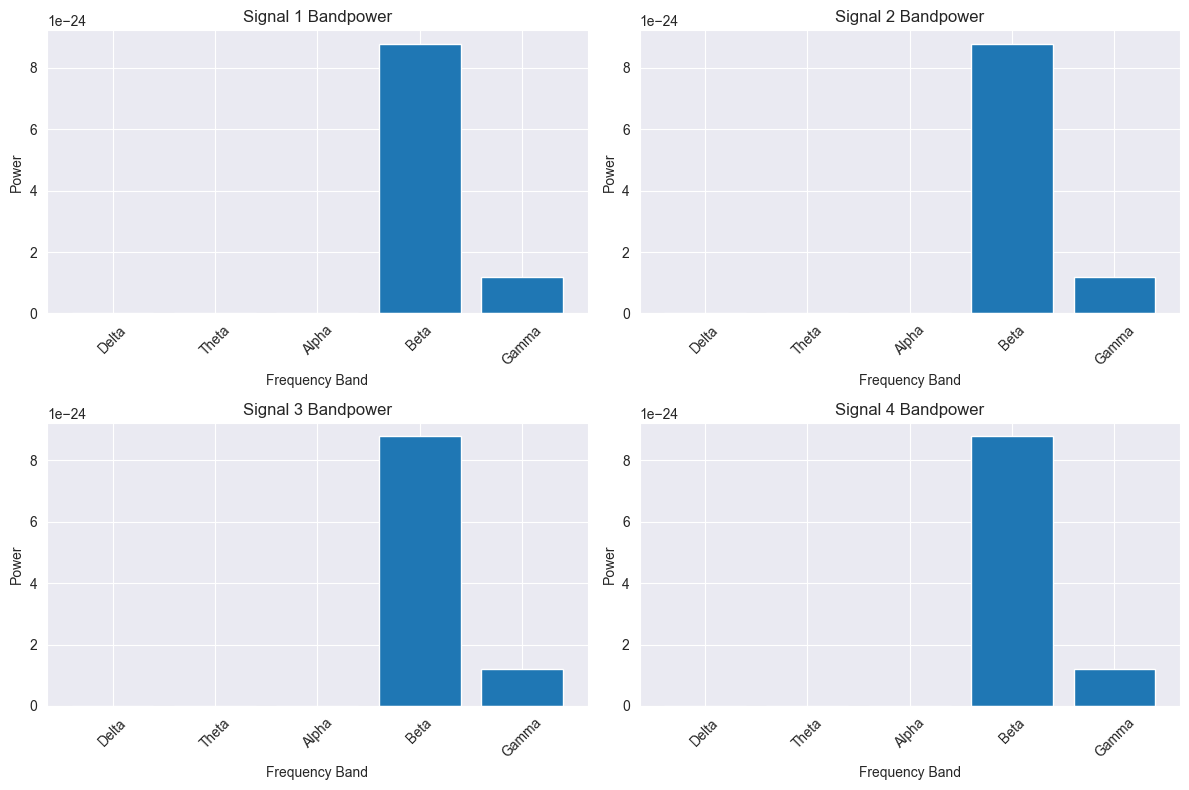

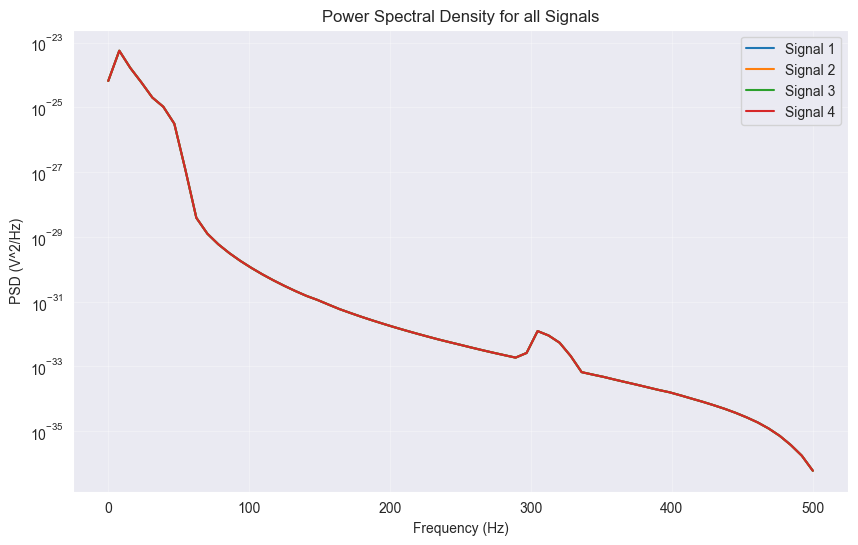

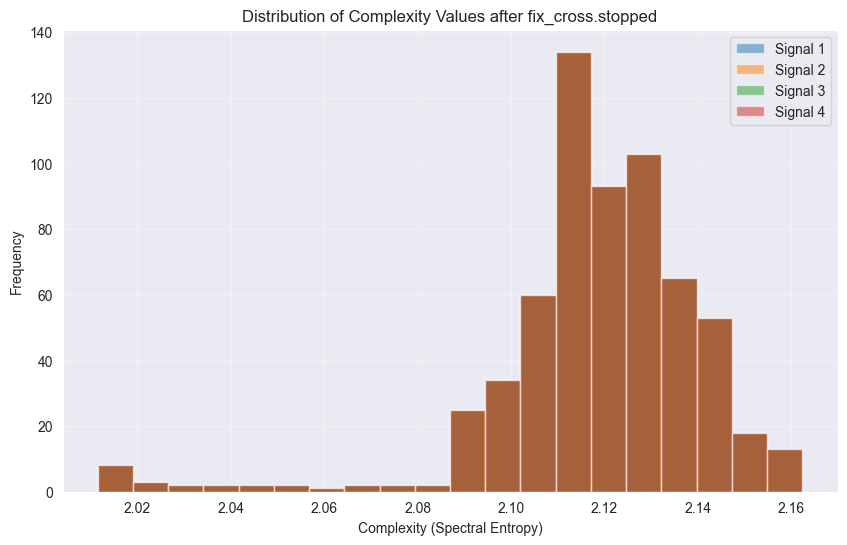

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_84086/2397322130.py:194: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(complexities_to_plot, labels=labels)


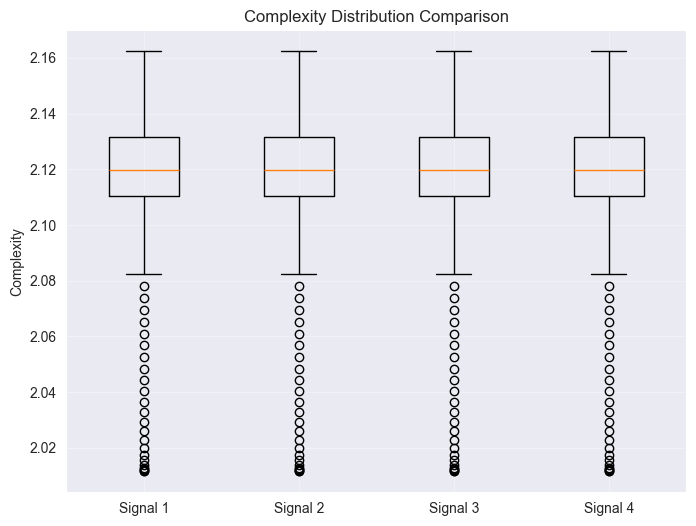

In [43]:
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Define bands
bands = [(1, 4), (4, 8), (8, 13), (13, 30), (30, 40)]
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Define window for complexity (2 seconds after fix_cross.stopped)
window_duration = 2  # seconds
sfreq = raw.info['sfreq']
window_samples = int(window_duration * sfreq)

# Store results for each signal
signals_data = []

for i in range(1, 5):
    print(f"\n{'='*50}")
    print(f"Signal {i}")
    print(f"{'='*50}")

    # Get word boundaries
    start_idx = (i-1) * 624
    end_idx = i * 624

    # Extract the words and data for this signal
    signal_words = df1[start_idx:end_idx]['words'].values
    signal_data = df1[start_idx:end_idx]  # Assuming your EEG data is in df1

    print(f"Unique words: {len(set(signal_words))}")
    print(f"Total samples: {len(signal_words)}")

    # ============================================
    # 1. Bandpower Spectrum for each signal
    # ============================================
    print("\n--- Bandpower Spectrum ---")

    # Assuming your EEG signal is in a column called 'eeg' or similar
    # Adjust column name as needed
    ch_name = raw.ch_names[0]
    # print(ch_name)
    eeg_signal = raw.get_data(picks=[ch_name])[0]   # numpy array (n_samples,)
    print(eeg_signal.shape)
    print(eeg_signal)
    # eeg_signal = signal_data['eeg'].values  # Replace 'eeg' with your actual column name

    # Compute PSD using Welch
    win_len = min(128, len(eeg_signal))
    freqs, psd = welch(eeg_signal, fs=sfreq, nperseg=win_len)

    # Calculate band powers
    band_powers = {}
    for (low, high), name in zip(bands, band_names):
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        band_power = np.trapz(psd[idx_band], freqs[idx_band])
        band_powers[name] = band_power
        print(f"{name} ({low}-{high} Hz): {band_power:.4f}")

    # Store bandpowers
    signals_data.append({
        'signal_num': i,
        'band_powers': band_powers,
        'freqs': freqs,
        'psd': psd
    })

    # ============================================
    # 2. Complexity values after fix_cross.stopped
    # ============================================
    print("\n--- Complexity Analysis ---")

    # Find indices where fix_cross.stopped occurs within this signal
    # Adjust column name as needed
    fix_cross_stopped_indices = signal_data[signal_data['fix_cross.stopped'].notna()].index

    complexity_values = []

    for idx in fix_cross_stopped_indices:
        # Get the index within the signal
        local_idx = idx - start_idx

        # Get 2-second window after fix_cross.stopped
        window_start = local_idx
        window_end = min(local_idx + window_samples, len(eeg_signal))

        if window_end - window_start >= window_samples * 0.5:  # At least 50% of window available
            window_data = eeg_signal[window_start:window_end]

            # Calculate complexity (Sample Entropy or Approximate Entropy)
            # Option 1: Sample Entropy
            def sample_entropy(time_series, m=2, r=None):
                if r is None:
                    r = 0.2 * np.std(time_series)
                N = len(time_series)

                def _maxdist(xi, xj):
                    return max(abs(xi - xj))

                def _phi(m):
                    x = np.array([time_series[i:i+m] for i in range(N - m + 1)])
                    C = 0
                    for i in range(N - m + 1):
                        for j in range(N - m + 1):
                            if i != j and _maxdist(x[i], x[j]) <= r:
                                C += 1
                    return C / ((N - m + 1) * (N - m))

                return -np.log(_phi(m+1) / _phi(m))

            # Option 2: Spectral Entropy (based on PSD)
            def spectral_entropy(signal, sfreq):
                freqs, psd = welch(signal, fs=sfreq, nperseg=min(128, len(signal)))
                psd_norm = psd / np.sum(psd)
                return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

            # Choose one complexity measure:
            # complexity = sample_entropy(window_data)
            complexity = spectral_entropy(window_data, sfreq)
            complexity_values.append(complexity)

    # Statistics of complexity values
    if len(complexity_values) > 0:
        print(f"Number of fix_cross.stopped events: {len(complexity_values)}")
        print(f"Complexity - Mean: {np.mean(complexity_values):.4f}")
        print(f"Complexity - Std: {np.std(complexity_values):.4f}")
        print(f"Complexity - Median: {np.median(complexity_values):.4f}")
        print(f"Complexity - Min: {np.min(complexity_values):.4f}")
        print(f"Complexity - Max: {np.max(complexity_values):.4f}")

        # Distribution statistics
        percentiles = [25, 50, 75, 90, 95]
        for p in percentiles:
            print(f"Complexity - {p}th percentile: {np.percentile(complexity_values, p):.4f}")

        signals_data[-1]['complexity_values'] = complexity_values
    else:
        print("No valid complexity windows found")
        signals_data[-1]['complexity_values'] = []

# ============================================
# Visualization
# ============================================

# Plot bandpowers for all signals
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, signal_data in enumerate(signals_data):
    ax = axes[i]
    bands_list = list(signal_data['band_powers'].keys())
    powers = list(signal_data['band_powers'].values())

    ax.bar(bands_list, powers)
    ax.set_title(f'Signal {signal_data["signal_num"]} Bandpower')
    ax.set_ylabel('Power')
    ax.set_xlabel('Frequency Band')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot PSDs
plt.figure(figsize=(10, 6))
for signal_data in signals_data:
    plt.semilogy(signal_data['freqs'], signal_data['psd'],
                 label=f'Signal {signal_data["signal_num"]}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.title('Power Spectral Density for all Signals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot complexity distributions
plt.figure(figsize=(10, 6))
for signal_data in signals_data:
    if len(signal_data['complexity_values']) > 0:
        plt.hist(signal_data['complexity_values'], alpha=0.5,
                 label=f'Signal {signal_data["signal_num"]}', bins=20)
plt.xlabel('Complexity (Spectral Entropy)')
plt.ylabel('Frequency')
plt.title('Distribution of Complexity Values after fix_cross.stopped')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Boxplot of complexities
plt.figure(figsize=(8, 6))
complexities_to_plot = [signal_data['complexity_values'] for signal_data in signals_data
                        if len(signal_data['complexity_values']) > 0]
labels = [f'Signal {i+1}' for i in range(len(complexities_to_plot))]
plt.boxplot(complexities_to_plot, labels=labels)
plt.ylabel('Complexity')
plt.title('Complexity Distribution Comparison')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# First, print the actual bandpower values to see the magnitude difference
for i, signal_data in enumerate(signals_data):
    print(f"\nSignal {signal_data['signal_num']} Bandpowers:")
    for band, power in signal_data['band_powers'].items():
        print(f"  {band}: {power:.6f}")


Signal 1 Bandpowers:
  Delta: 0.000000
  Theta: 0.000000
  Alpha: 0.000000
  Beta: 0.000000
  Gamma: 0.000000

Signal 2 Bandpowers:
  Delta: 0.000000
  Theta: 0.000000
  Alpha: 0.000000
  Beta: 0.000000
  Gamma: 0.000000

Signal 3 Bandpowers:
  Delta: 0.000000
  Theta: 0.000000
  Alpha: 0.000000
  Beta: 0.000000
  Gamma: 0.000000

Signal 4 Bandpowers:
  Delta: 0.000000
  Theta: 0.000000
  Alpha: 0.000000
  Beta: 0.000000
  Gamma: 0.000000



Signal 1
Unique words: 623
Total samples: 624

--- Bandpower Spectrum ---
Delta (1-4 Hz): 0.0000
Theta (4-8 Hz): 0.0000
Alpha (8-13 Hz): 0.0000
Beta (13-30 Hz): 0.0000
Gamma (30-40 Hz): 0.0000

--- Complexity Analysis ---
Number of fix_cross.stopped events: 624
Complexity - Mean: 2.1183
Complexity - Std: 0.0228
Complexity - Median: 2.1196
Complexity - Min: 2.0115
Complexity - Max: 2.1623
Complexity - 25th percentile: 2.1104
Complexity - 50th percentile: 2.1196
Complexity - 75th percentile: 2.1317
Complexity - 90th percentile: 2.1423
Complexity - 95th percentile: 2.1470

Signal 2
Unique words: 623
Total samples: 624

--- Bandpower Spectrum ---
Delta (1-4 Hz): 0.0000
Theta (4-8 Hz): 0.0000
Alpha (8-13 Hz): 0.0000
Beta (13-30 Hz): 0.0000
Gamma (30-40 Hz): 0.0000

--- Complexity Analysis ---


/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_84086/977469874.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.trapz(psd[idx_band], freqs[idx_band])


Number of fix_cross.stopped events: 624
Complexity - Mean: 2.1183
Complexity - Std: 0.0228
Complexity - Median: 2.1196
Complexity - Min: 2.0115
Complexity - Max: 2.1623
Complexity - 25th percentile: 2.1104
Complexity - 50th percentile: 2.1196
Complexity - 75th percentile: 2.1317
Complexity - 90th percentile: 2.1423
Complexity - 95th percentile: 2.1470

Signal 3
Unique words: 623
Total samples: 624

--- Bandpower Spectrum ---
Delta (1-4 Hz): 0.0000
Theta (4-8 Hz): 0.0000
Alpha (8-13 Hz): 0.0000
Beta (13-30 Hz): 0.0000
Gamma (30-40 Hz): 0.0000

--- Complexity Analysis ---
Number of fix_cross.stopped events: 624
Complexity - Mean: 2.1183
Complexity - Std: 0.0228
Complexity - Median: 2.1196
Complexity - Min: 2.0115
Complexity - Max: 2.1623
Complexity - 25th percentile: 2.1104
Complexity - 50th percentile: 2.1196
Complexity - 75th percentile: 2.1317
Complexity - 90th percentile: 2.1423
Complexity - 95th percentile: 2.1470

Signal 4
Unique words: 623
Total samples: 624

--- Bandpower Spectru

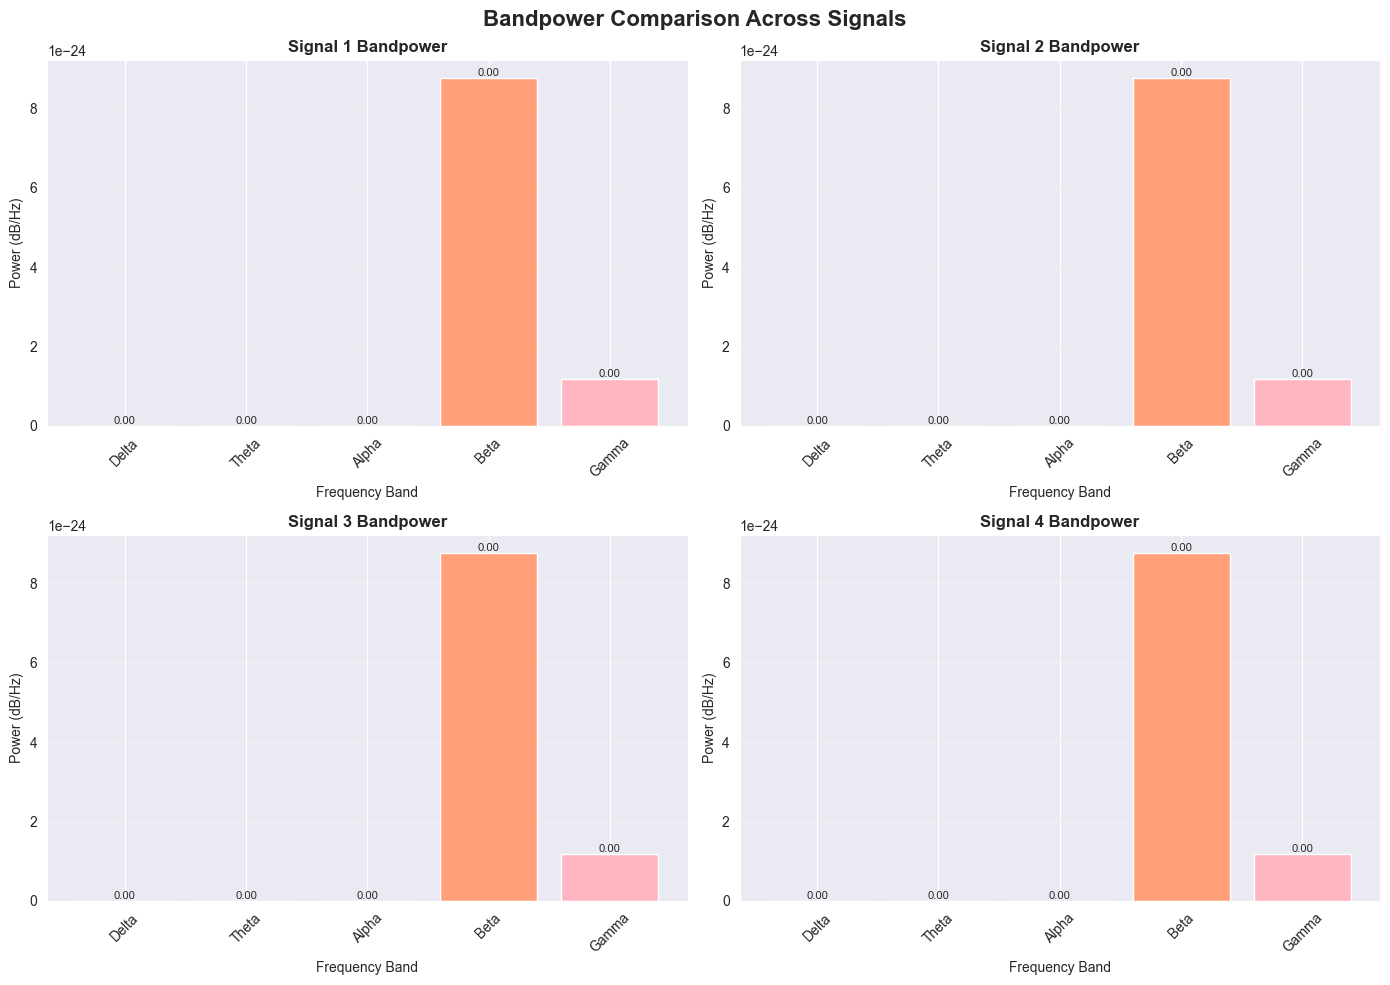

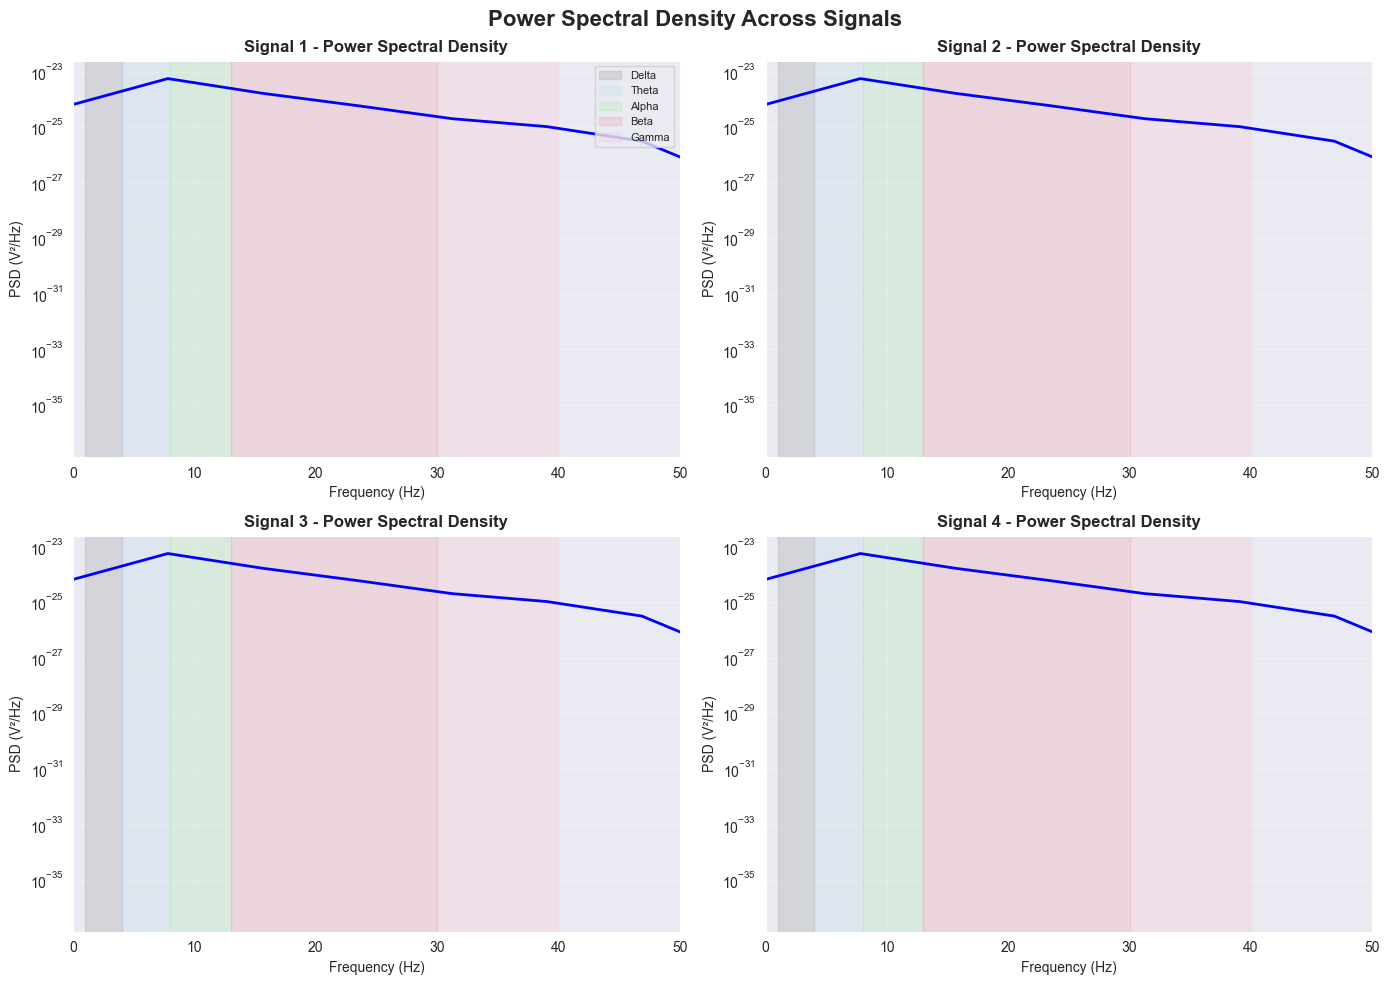

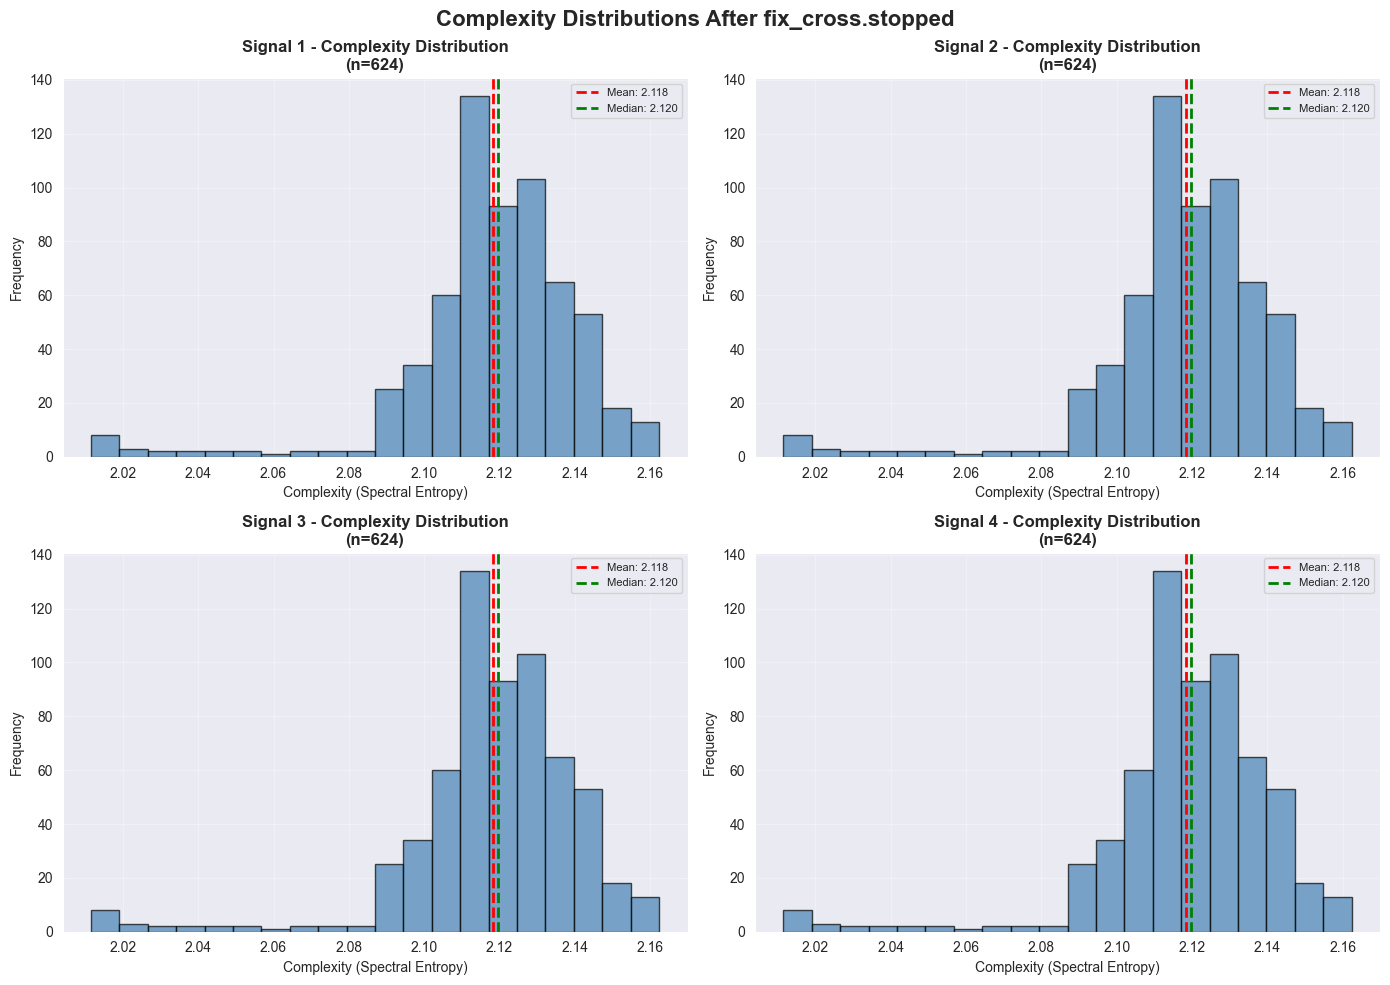

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_84086/977469874.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(complexities_to_plot, labels=labels, patch_artist=True)


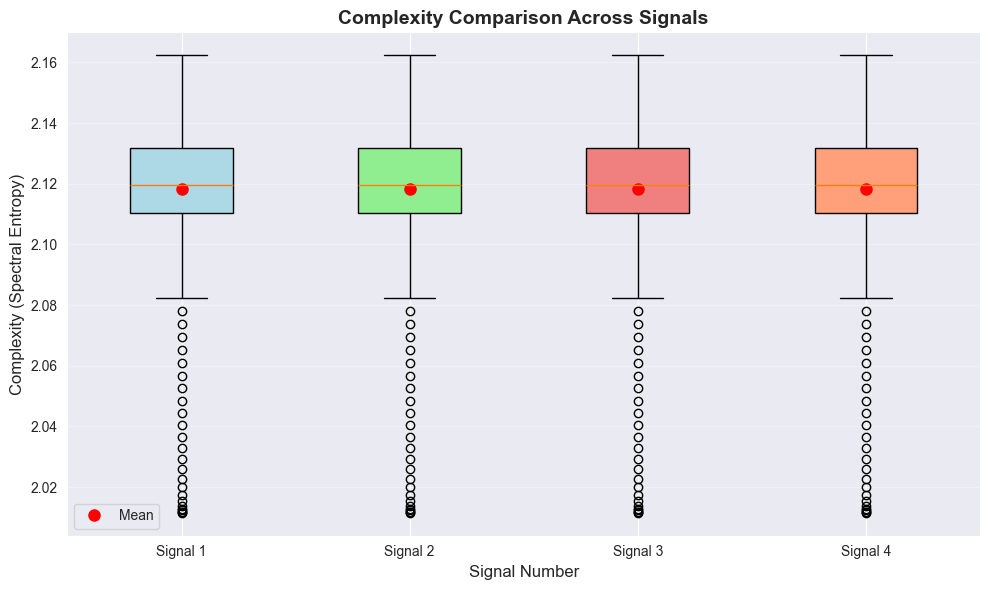


SUMMARY STATISTICS TABLE
 Signal  N_events     Mean      Std   Median      Min      Max
      1       624 2.118288 0.022834 2.119636 2.011533 2.162345
      2       624 2.118288 0.022834 2.119636 2.011533 2.162345
      3       624 2.118288 0.022834 2.119636 2.011533 2.162345
      4       624 2.118288 0.022834 2.119636 2.011533 2.162345

BANDPOWER SUMMARY TABLE
 Signal  Delta  Theta  Alpha         Beta        Gamma
      1    0.0    0.0    0.0 8.772574e-24 1.194833e-24
      2    0.0    0.0    0.0 8.772574e-24 1.194833e-24
      3    0.0    0.0    0.0 8.772574e-24 1.194833e-24
      4    0.0    0.0    0.0 8.772574e-24 1.194833e-24


In [39]:
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Define bands
bands = [(1, 4), (4, 8), (8, 13), (13, 30), (30, 40)]
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Define window for complexity (2 seconds after fix_cross.stopped)
window_duration = 2  # seconds
sfreq = raw.info['sfreq']
window_samples = int(window_duration * sfreq)

# Store results for each signal
signals_data = []

for i in range(1, 5):
    print(f"\n{'='*50}")
    print(f"Signal {i}")
    print(f"{'='*50}")

    # Get word boundaries
    start_idx = (i-1) * 624
    end_idx = i * 624

    # Extract the words and data for this signal
    signal_words = df1[start_idx:end_idx]['words'].values
    signal_data = df1[start_idx:end_idx]

    print(f"Unique words: {len(set(signal_words))}")
    print(f"Total samples: {len(signal_words)}")

    # ============================================
    # 1. Bandpower Spectrum for each signal
    # ============================================
    print("\n--- Bandpower Spectrum ---")

    # Get EEG signal
    ch_name = raw.ch_names[0]
    eeg_signal = raw.get_data(picks=[ch_name])[0]

    # Compute PSD using Welch
    win_len = min(128, len(eeg_signal))
    freqs, psd = welch(eeg_signal, fs=sfreq, nperseg=win_len)

    # Calculate band powers
    band_powers = {}
    for (low, high), name in zip(bands, band_names):
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        band_power = np.trapz(psd[idx_band], freqs[idx_band])
        band_powers[name] = band_power
        print(f"{name} ({low}-{high} Hz): {band_power:.4f}")

    # Store bandpowers
    signals_data.append({
        'signal_num': i,
        'band_powers': band_powers,
        'freqs': freqs,
        'psd': psd
    })

    # ============================================
    # 2. Complexity values after fix_cross.stopped
    # ============================================
    print("\n--- Complexity Analysis ---")

    # Find indices where fix_cross.stopped occurs within this signal
    fix_cross_stopped_indices = signal_data[signal_data['fix_cross.stopped'].notna()].index

    complexity_values = []

    for idx in fix_cross_stopped_indices:
        # Get the index within the signal
        local_idx = idx - start_idx

        # Get 2-second window after fix_cross.stopped
        window_start = local_idx
        window_end = min(local_idx + window_samples, len(eeg_signal))

        if window_end - window_start >= window_samples * 0.5:
            window_data = eeg_signal[window_start:window_end]

            def spectral_entropy(signal, sfreq):
                freqs, psd = welch(signal, fs=sfreq, nperseg=min(128, len(signal)))
                psd_norm = psd / np.sum(psd)
                return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

            complexity = spectral_entropy(window_data, sfreq)
            complexity_values.append(complexity)

    # Statistics of complexity values
    if len(complexity_values) > 0:
        print(f"Number of fix_cross.stopped events: {len(complexity_values)}")
        print(f"Complexity - Mean: {np.mean(complexity_values):.4f}")
        print(f"Complexity - Std: {np.std(complexity_values):.4f}")
        print(f"Complexity - Median: {np.median(complexity_values):.4f}")
        print(f"Complexity - Min: {np.min(complexity_values):.4f}")
        print(f"Complexity - Max: {np.max(complexity_values):.4f}")

        percentiles = [25, 50, 75, 90, 95]
        for p in percentiles:
            print(f"Complexity - {p}th percentile: {np.percentile(complexity_values, p):.4f}")

        signals_data[-1]['complexity_values'] = complexity_values
    else:
        print("No valid complexity windows found")
        signals_data[-1]['complexity_values'] = []

# ============================================
# Visualization - All 4 signals on subplots
# ============================================

# 1. Bandpower Bar Plots (2x2 grid)
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
axes1 = axes1.flatten()

for i, signal_data in enumerate(signals_data):
    ax = axes1[i]
    bands_list = list(signal_data['band_powers'].keys())
    powers = list(signal_data['band_powers'].values())

    bars = ax.bar(bands_list, powers, color=['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightpink'])
    ax.set_title(f'Signal {signal_data["signal_num"]} Bandpower', fontsize=12, fontweight='bold')
    ax.set_ylabel('Power (dB/Hz)', fontsize=10)
    ax.set_xlabel('Frequency Band', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, power in zip(bars, powers):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{power:.2f}', ha='center', va='bottom', fontsize=8)

fig1.suptitle('Bandpower Comparison Across Signals', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Power Spectral Densities (2x2 grid)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
axes2 = axes2.flatten()

for i, signal_data in enumerate(signals_data):
    ax = axes2[i]
    ax.semilogy(signal_data['freqs'], signal_data['psd'], linewidth=2, color='blue')
    ax.set_xlabel('Frequency (Hz)', fontsize=10)
    ax.set_ylabel('PSD (V²/Hz)', fontsize=10)
    ax.set_title(f'Signal {signal_data["signal_num"]} - Power Spectral Density', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 50])  # Limit to relevant frequencies

    # Shade frequency bands
    for (low, high), name, color in zip(bands, band_names, ['gray', 'lightblue', 'lightgreen', 'lightcoral', 'lightpink']):
        ax.axvspan(low, high, alpha=0.2, color=color, label=name if i==0 else "")

    if i == 0:  # Add legend only for first subplot
        ax.legend(loc='upper right', fontsize=8)

fig2.suptitle('Power Spectral Density Across Signals', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Complexity Distributions (2x2 grid for histograms)
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
axes3 = axes3.flatten()

for i, signal_data in enumerate(signals_data):
    ax = axes3[i]
    if len(signal_data['complexity_values']) > 0:
        ax.hist(signal_data['complexity_values'], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        ax.axvline(np.mean(signal_data['complexity_values']), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(signal_data["complexity_values"]):.3f}')
        ax.axvline(np.median(signal_data['complexity_values']), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(signal_data["complexity_values"]):.3f}')
        ax.set_xlabel('Complexity (Spectral Entropy)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'Signal {signal_data["signal_num"]} - Complexity Distribution\n(n={len(signal_data["complexity_values"])})', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No valid complexity data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Signal {signal_data["signal_num"]}', fontsize=12, fontweight='bold')

fig3.suptitle('Complexity Distributions After fix_cross.stopped', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Combined Boxplot for Complexity (single plot with all 4 signals)
fig4, ax4 = plt.subplots(figsize=(10, 6))
complexities_to_plot = [signal_data['complexity_values'] for signal_data in signals_data]
labels = [f'Signal {i+1}' for i in range(len(complexities_to_plot))]

bp = ax4.boxplot(complexities_to_plot, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon']):
    patch.set_facecolor(color)

ax4.set_ylabel('Complexity (Spectral Entropy)', fontsize=12)
ax4.set_xlabel('Signal Number', fontsize=12)
ax4.set_title('Complexity Comparison Across Signals', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add mean markers
for i, complexities in enumerate(complexities_to_plot):
    if len(complexities) > 0:
        mean_val = np.mean(complexities)
        ax4.plot(i+1, mean_val, 'ro', markersize=8, label='Mean' if i==0 else "")

ax4.legend()
plt.tight_layout()
plt.show()

# 5. Summary Statistics Table (text-based)
print("\n" + "="*80)
print("SUMMARY STATISTICS TABLE")
print("="*80)

summary_data = []
for signal_data in signals_data:
    complexities = signal_data['complexity_values']
    if len(complexities) > 0:
        summary_data.append({
            'Signal': signal_data['signal_num'],
            'N_events': len(complexities),
            'Mean': np.mean(complexities),
            'Std': np.std(complexities),
            'Median': np.median(complexities),
            'Min': np.min(complexities),
            'Max': np.max(complexities)
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# 6. Bandpower Summary Table
print("\n" + "="*80)
print("BANDPOWER SUMMARY TABLE")
print("="*80)

bandpower_data = []
for signal_data in signals_data:
    row = {'Signal': signal_data['signal_num']}
    row.update(signal_data['band_powers'])
    bandpower_data.append(row)

bandpower_df = pd.DataFrame(bandpower_data)
print(bandpower_df.to_string(index=False))

# 1. The Shift to Frontal Lobe Engagement (Reanalysis & Working Memory)


get frontal regions

In [29]:
import mne
import numpy as np
from scipy.signal import coherence
from itertools import combinations
import matplotlib.pyplot as plt
from tqdm import tqdm

frontal_sensors = [sensor for sensor, region in sensor_regions.items()
                   if 'Frontal' in region]

# Pick only frontal MEG channels
frontal_picks = [raw.ch_names.index(s) for s in frontal_sensors if s in raw.ch_names]
frontal_data = raw.get_data()[frontal_picks, :]
frontal_names = [raw.ch_names[i] for i in frontal_picks]
n_frontal = len(frontal_names)

print(f"Total MEG channels: {len(mne.pick_types(raw.info, meg=True))}")
print(f"Frontal channels selected: {n_frontal}")
print(f"First 10 frontal channels: {frontal_names[:10]}")

# Define your time windows (in seconds)
# ADJUST THESE BASED ON YOUR EXPERIMENT!
t1, t2 = 263.64819549999993, 1688.5422448999998     # First window (e.g., baseline)
t3, t4 = 1688.5422448999998, 2947.8042822999996     # Second window (e.g., stimulation)

# Convert to samples
sfreq = raw.info['sfreq']
s1, s2 = int(t1 * sfreq), int(t2 * sfreq)
s3, s4 = int(t3 * sfreq), int(t4 * sfreq)

print(f"\nTime window 1: {t1}-{t2}s (samples {s1}-{s2})")
print(f"Time window 2: {t3}-{t4}s (samples {s3}-{s4})")

Total MEG channels: 306
Frontal channels selected: 75
First 10 frontal channels: ['MEG0113', 'MEG0112', 'MEG0111', 'MEG0122', 'MEG0123', 'MEG0121', 'MEG0313', 'MEG0312', 'MEG0311', 'MEG0322']

Time window 1: 263.64819549999993-1688.5422448999998s (samples 263648-1688542)
Time window 2: 1688.5422448999998-2947.8042822999996s (samples 1688542-2947804)


In [30]:
data_window1 = frontal_data[:, s1:s2]
data_window2 = frontal_data[:, s3:s4]

# Calculate coherence for all frontal channel pairs
def compute_all_coherences(data, sfreq, nperseg=256):
    """
    Compute coherence for all pairs of channels
    Returns: dictionary mapping (ch1, ch2) -> coherence at each frequency
    """
    n_ch = data.shape[0]
    coherences = {}

    # Create all unique pairs
    pairs = list(combinations(range(n_ch), 2))

    for i, j in tqdm(pairs, desc="Computing coherence"):
        f, Cxy = coherence(data[i], data[j], sfreq, nperseg=nperseg)
        coherences[(i, j)] = Cxy

    return f, coherences

# Compute for both windows
print("\nComputing coherence for window 1 (frontal channels)...")
freqs, coh_window1 = compute_all_coherences(data_window1, sfreq)

print("\nComputing coherence for window 2 (frontal channels)...")
_, coh_window2 = compute_all_coherences(data_window2, sfreq)


Computing coherence for window 1 (frontal channels)...


Computing coherence: 100%|██████████| 2775/2775 [01:48<00:00, 25.65it/s]



Computing coherence for window 2 (frontal channels)...


Computing coherence: 100%|██████████| 2775/2775 [01:34<00:00, 29.34it/s]



Results for frontal channels in frequency band (8, 12) Hz:
Total frontal channel pairs: 2775
Pairs with better coherence in window 1 (263.64819549999993-1688.5422448999998s): 1442
Pairs with better coherence in window 2 (1688.5422448999998-2947.8042822999996s): 1333

Top 10 frontal channel pairs with largest coherence differences:
--------------------------------------------------------------------------------
1. MEG1412 - MEG1423: diff=-0.2504 (higher in window2)
2. MEG0923 - MEG1412: diff=-0.2503 (higher in window2)
3. MEG1411 - MEG1423: diff=-0.2495 (higher in window2)
4. MEG0922 - MEG1213: diff=-0.2332 (higher in window2)
5. MEG1223 - MEG1423: diff=-0.2263 (higher in window2)
6. MEG0922 - MEG1223: diff=-0.2188 (higher in window2)
7. MEG0922 - MEG1423: diff=-0.2093 (higher in window2)
8. MEG0912 - MEG1213: diff=-0.2075 (higher in window2)
9. MEG1213 - MEG1423: diff=-0.2065 (higher in window2)
10. MEG0923 - MEG1422: diff=-0.2053 (higher in window2)


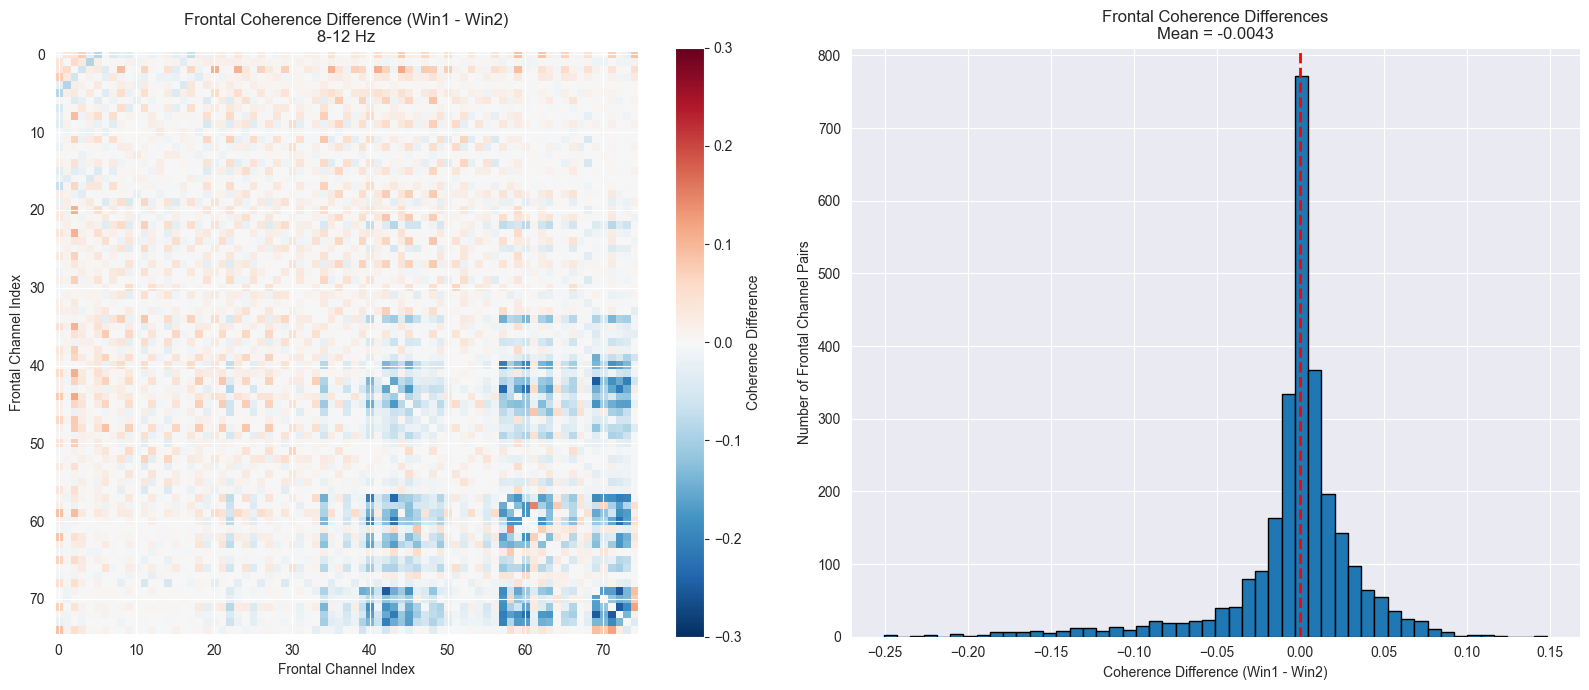

In [31]:
# Define frequency band of interest (e.g., alpha: 8-12 Hz)
freq_band = (8, 12)  # Adjust based on your interest
freq_idx = np.where((freqs >= freq_band[0]) & (freqs <= freq_band[1]))[0]

# Compare coherence between windows
better_in_window1 = []
better_in_window2 = []
coherence_diff = {}

for pair in coh_window1.keys():
    mean_coh1 = np.mean(coh_window1[pair][freq_idx])
    mean_coh2 = np.mean(coh_window2[pair][freq_idx])

    diff = mean_coh1 - mean_coh2
    coherence_diff[pair] = diff

    if diff > 0:
        better_in_window1.append((pair, diff))
    else:
        better_in_window2.append((pair, -diff))

print(f"\nResults for frontal channels in frequency band {freq_band} Hz:")
print(f"Total frontal channel pairs: {len(coherence_diff)}")
print(f"Pairs with better coherence in window 1 ({t1}-{t2}s): {len(better_in_window1)}")
print(f"Pairs with better coherence in window 2 ({t3}-{t4}s): {len(better_in_window2)}")

# Find top frontal pairs with biggest differences
sorted_pairs = sorted(coherence_diff.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nTop 10 frontal channel pairs with largest coherence differences:")
print("-" * 80)
for i, ((ch1, ch2), diff) in enumerate(sorted_pairs[:10]):
    ch1_name = frontal_names[ch1]
    ch2_name = frontal_names[ch2]
    direction = "higher in window1" if diff > 0 else "higher in window2"
    print(f"{i+1}. {ch1_name} - {ch2_name}: diff={diff:.4f} ({direction})")

# Visualize frontal coherence difference matrix
diff_matrix = np.zeros((n_frontal, n_frontal))

for (ch1, ch2), diff in coherence_diff.items():
    diff_matrix[ch1, ch2] = diff
    diff_matrix[ch2, ch1] = diff

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Difference matrix
im = axes[0].imshow(diff_matrix, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0].set_title(f'Frontal Coherence Difference (Win1 - Win2)\n{freq_band[0]}-{freq_band[1]} Hz')
axes[0].set_xlabel('Frontal Channel Index')
axes[0].set_ylabel('Frontal Channel Index')
plt.colorbar(im, ax=axes[0], label='Coherence Difference')

# Histogram of differences
axes[1].hist([d for d in coherence_diff.values()], bins=50, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Coherence Difference (Win1 - Win2)')
axes[1].set_ylabel('Number of Frontal Channel Pairs')
axes[1].set_title(f'Frontal Coherence Differences\nMean = {np.mean(list(coherence_diff.values())):.4f}')

plt.tight_layout()
plt.show()

In [32]:
mean_coh1 = np.mean([np.mean(c) for c in coh_window1.values()])
mean_coh2 = np.mean([np.mean(c) for c in coh_window2.values()])

print(f"\n{'='*60}")
print(f"FRONTAL COHERENCE SUMMARY")
print(f"{'='*60}")
print(f"Mean coherence across ALL frontal pairs in window1 ({t1}-{t2}s): {mean_coh1:.4f}")
print(f"Mean coherence across ALL frontal pairs in window2 ({t3}-{t4}s): {mean_coh2:.4f}")
print(f"Difference (Win1 - Win2): {mean_coh1 - mean_coh2:.4f}")

if mean_coh1 > mean_coh2:
    print(f"\n✓ Frontal coherence is HIGHER in window1 ({t1}-{t2}s)")
else:
    print(f"\n✓ Frontal coherence is HIGHER in window2 ({t3}-{t4}s)")

# Optional: Save results
import json
# Convert tuple keys to strings for JSON
results_to_save = {
    f"{frontal_names[ch1]}_{frontal_names[ch2]}": diff
    for (ch1, ch2), diff in coherence_diff.items()
}

with open('frontal_coherence_differences.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)
print(f"\nSaved frontal coherence results to 'frontal_coherence_differences.json'")


FRONTAL COHERENCE SUMMARY
Mean coherence across ALL frontal pairs in window1 (263.64819549999993-1688.5422448999998s): 0.0663
Mean coherence across ALL frontal pairs in window2 (1688.5422448999998-2947.8042822999996s): 0.0710
Difference (Win1 - Win2): -0.0047

✓ Frontal coherence is HIGHER in window2 (1688.5422448999998-2947.8042822999996s)

Saved frontal coherence results to 'frontal_coherence_differences.json'
